In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import os
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle


sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from torch.nn import CrossEntropyLoss
from losses.ewc import EWCCriterion
from losses.lwf import LwFCriterion
from utils import run_til_experiment, run_cil_experiment, new_model_from_backbone


In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [26]:
models = ["Naive", "EWC", "LwF", "Co2L"]
modes = ["til", "cil"]
val_accs = pd.DataFrame(columns=models, index=modes)
test_accs = pd.DataFrame(columns=models, index=modes)
all_val_accs_dic = {model: {mode: [] for mode in modes} for model in models}

## Naive

#### Naive TIL

In [27]:
model = new_model_from_backbone(device)
criterion = CrossEntropyLoss()
model_name = "Naive"
mode_name = "til"
all_val_accs, avg_val_acc, avg_test_acc = run_til_experiment(model, criterion, "Naive", epochs=250, lr=1e-2)
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_test_acc
all_val_accs_dic[model_name][mode_name] = all_val_accs

Files already downloaded and verified


c:\Users\User\miniconda3\envs\vision\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


Epochs: 100%|██████████| 250/250 [00:33<00:00,  7.51epoch/s, loss=0.00157] 


|0: 0.9760|
Avg accuracy: 0.9760
Training task 1


...

|0: 0.9760||1: 0.6800||2: 0.7200|
Avg accuracy: 0.7920
Training task 3


Epochs: 100%|██████████| 250/250 [00:33<00:00,  7.57epoch/s, loss=0.475]


|0: 0.9760||1: 0.6800||2: 0.7200||3: 0.7760|
Avg accuracy: 0.7880
Training task 4


Epochs: 100%|██████████| 250/250 [00:31<00:00,  8.06epoch/s, loss=0.388]


|0: 0.9760||1: 0.6800||2: 0.7200||3: 0.7760||4: 0.8300|
Avg accuracy: 0.7964
|0: 0.9740||1: 0.6790||2: 0.6970||3: 0.7615||4: 0.8350|
Avg accuracy: 0.7893


#### Naive CIL

In [36]:
model = new_model_from_backbone(device)
criterion = CrossEntropyLoss()
model_name = "Naive"
mode_name = "cil"
all_val_accs, avg_val_acc, avg_test_acc = run_cil_experiment(model, criterion, "Naive", epochs=5, lr=1e-2)
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_test_acc
all_val_accs_dic[model_name][mode_name] = all_val_accs

Files already downloaded and verified


c:\Users\User\miniconda3\envs\vision\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


Epochs: 100%|██████████| 5/5 [00:00<00:00, 10.69epoch/s, loss=0.172]


|0: 0.9730|
Avg accuracy: 0.9730
Training task 1


...

|0: 0.0000||1: 0.0000||2: 0.6030|
Avg accuracy: 0.2010
Training task 3


Epochs: 100%|██████████| 5/5 [00:00<00:00,  9.93epoch/s, loss=0.671]


|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.6230|
Avg accuracy: 0.1557
Training task 4


Epochs: 100%|██████████| 5/5 [00:00<00:00,  9.63epoch/s, loss=0.524]


|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.0000||4: 0.7540|
Avg accuracy: 0.1508
|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.0000||4: 0.7585|
Avg accuracy: 0.1517


### Results

In [29]:
print(val_accs)
print(test_accs)
print(all_val_accs_dic["Naive"])

      Naive  EWC  LwF Co2L
til  0.7964  NaN  NaN  NaN
cil  0.1516  NaN  NaN  NaN
      Naive  EWC  LwF Co2L
til  0.7893  NaN  NaN  NaN
cil  0.1515  NaN  NaN  NaN
{'til': [[0.976], [0.976, 0.68], [0.976, 0.68, 0.72], [0.976, 0.68, 0.72, 0.776], [0.976, 0.68, 0.72, 0.776, 0.83]], 'cil': [[0.973], [0.0, 0.564], [0.0, 0.0, 0.526], [0.0, 0.0, 0.0, 0.577], [0.0, 0.0, 0.0, 0.0, 0.758]]}


## EWC

#### EWC TIL

In [30]:
model = new_model_from_backbone(device)
model_name = "EWC"
mode_name = "til"
criterion = EWCCriterion(CrossEntropyLoss(), lambda_=1, model=model)
all_val_accs, avg_val_acc, avg_test_acc = run_til_experiment(model, criterion, "EWC", epochs=250, lr=1e-2)
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_test_acc
all_val_accs_dic[model_name][mode_name] = all_val_accs

Files already downloaded and verified


c:\Users\User\miniconda3\envs\vision\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


Epochs: 100%|██████████| 250/250 [00:34<00:00,  7.23epoch/s, loss=0.00157] 


|0: 0.9760|
Avg accuracy: 0.9760
Training task 1


...

|0: 0.9760||1: 0.6780||2: 0.7210|
Avg accuracy: 0.7917
Training task 3


Epochs: 100%|██████████| 250/250 [00:43<00:00,  5.69epoch/s, loss=0.516]


|0: 0.9760||1: 0.6780||2: 0.7210||3: 0.7430|
Avg accuracy: 0.7795
Training task 4


Epochs: 100%|██████████| 250/250 [00:48<00:00,  5.11epoch/s, loss=0.332]


|0: 0.9760||1: 0.6780||2: 0.7210||3: 0.7430||4: 0.8200|
Avg accuracy: 0.7876
|0: 0.9740||1: 0.6825||2: 0.7030||3: 0.7385||4: 0.8320|
Avg accuracy: 0.7860


#### EWC CIL

In [31]:
model = new_model_from_backbone(device)
model_name = "EWC"
mode_name = "cil"
criterion = EWCCriterion(CrossEntropyLoss(), lambda_=1, global_labels=True, model=model)
# run_cil_experiment(model, criterion, "EWC", epochs=100, lr=1e-5, batch_size=1024)
all_val_accs, avg_val_acc, avg_test_acc  = run_cil_experiment(model, criterion, "EWC", epochs=5, lr=1e-2)
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_test_acc
all_val_accs_dic[model_name][mode_name] = all_val_accs


Files already downloaded and verified
Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


Epochs: 100%|██████████| 5/5 [00:00<00:00, 10.31epoch/s, loss=0.172]


|0: 0.9730|
Avg accuracy: 0.9730
Training task 1


Epochs: 100%|██████████| 5/5 [00:00<00:00,  9.56epoch/s, loss=0.634]


|0: 0.0000||1: 0.5780|
Avg accuracy: 0.2890
Training task 2


...

|0: 0.0000||1: 0.0000||2: 0.5540|
Avg accuracy: 0.1847
Training task 3


Epochs: 100%|██████████| 5/5 [00:00<00:00,  6.54epoch/s, loss=0.726]


|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.6410|
Avg accuracy: 0.1603
Training task 4


Epochs: 100%|██████████| 5/5 [00:00<00:00,  7.54epoch/s, loss=0.668]


|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.0000||4: 0.7490|
Avg accuracy: 0.1498
|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.0000||4: 0.7605|
Avg accuracy: 0.1521


### Results

In [32]:
print(val_accs)
print(test_accs)
print(all_val_accs_dic["EWC"])

      Naive     EWC  LwF Co2L
til  0.7964  0.7876  NaN  NaN
cil  0.1516  0.1498  NaN  NaN
      Naive     EWC  LwF Co2L
til  0.7893   0.786  NaN  NaN
cil  0.1515  0.1521  NaN  NaN
{'til': [[0.976], [0.976, 0.678], [0.976, 0.678, 0.721], [0.976, 0.678, 0.721, 0.743], [0.976, 0.678, 0.721, 0.743, 0.82]], 'cil': [[0.973], [0.0, 0.578], [0.0, 0.0, 0.554], [0.0, 0.0, 0.0, 0.641], [0.0, 0.0, 0.0, 0.0, 0.749]]}


## LwF

### LwF TIL

In [33]:
model = new_model_from_backbone(device)
model_name = "LwF"
mode_name = "til"
criterion = LwFCriterion(CrossEntropyLoss(), model, lambda_=1.0, temperature=2.0, cil_binary_distill=False)
all_val_accs, avg_val_acc, avg_test_acc = run_til_experiment(model, criterion, "LwF", epochs=250, lr=1e-2)
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_test_acc
all_val_accs_dic[model_name][mode_name] = all_val_accs


Files already downloaded and verified


c:\Users\User\miniconda3\envs\vision\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


Epochs: 100%|██████████| 250/250 [00:33<00:00,  7.45epoch/s, loss=0.00157] 


|0: 0.9760|
Avg accuracy: 0.9760
Training task 1


...

|0: 0.9760||1: 0.6790||2: 0.7200|
Avg accuracy: 0.7917
Training task 3


Epochs: 100%|██████████| 250/250 [00:38<00:00,  6.43epoch/s, loss=0.475]


|0: 0.9760||1: 0.6790||2: 0.7200||3: 0.7760|
Avg accuracy: 0.7877
Training task 4


Epochs: 100%|██████████| 250/250 [00:40<00:00,  6.17epoch/s, loss=0.389]


|0: 0.9760||1: 0.6760||2: 0.7200||3: 0.7740||4: 0.8300|
Avg accuracy: 0.7952
|0: 0.9740||1: 0.6805||2: 0.6970||3: 0.7620||4: 0.8350|
Avg accuracy: 0.7897


### LwF CIL

In [34]:
model = new_model_from_backbone(device)
model_name = "LwF"
mode_name = "cil"
criterion = LwFCriterion(CrossEntropyLoss(), model, lambda_=1.0, temperature=2.0, cil_binary_distill=False)
all_val_accs, avg_val_acc, avg_test_acc = run_cil_experiment(model, criterion, "LwF", epochs=5, lr=1e-2)
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_test_acc
all_val_accs_dic[model_name][mode_name] = all_val_accs

Files already downloaded and verified
Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


Epochs: 100%|██████████| 5/5 [00:00<00:00, 10.44epoch/s, loss=0.172]


|0: 0.9730|
Avg accuracy: 0.9730
Training task 1


Epochs: 100%|██████████| 5/5 [00:00<00:00,  9.33epoch/s, loss=0.646]


|0: 0.0000||1: 0.5820|
Avg accuracy: 0.2910
Training task 2


...

|0: 0.0000||1: 0.0000||2: 0.6030|
Avg accuracy: 0.2010
Training task 3


Epochs: 100%|██████████| 5/5 [00:00<00:00,  7.55epoch/s, loss=0.671]


|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.6230|
Avg accuracy: 0.1557
Training task 4


Epochs: 100%|██████████| 5/5 [00:00<00:00,  9.58epoch/s, loss=0.524]


|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.0000||4: 0.7540|
Avg accuracy: 0.1508
|0: 0.0000||1: 0.0000||2: 0.0000||3: 0.0000||4: 0.7585|
Avg accuracy: 0.1517


### Results

In [35]:
print(val_accs)
print(test_accs)
print(all_val_accs_dic["LwF"])

      Naive     EWC     LwF Co2L
til  0.7964  0.7876  0.7952  NaN
cil  0.1516  0.1498  0.1508  NaN
      Naive     EWC     LwF Co2L
til  0.7893   0.786  0.7897  NaN
cil  0.1515  0.1521  0.1517  NaN
{'til': [[0.976], [0.976, 0.68], [0.976, 0.679, 0.72], [0.976, 0.679, 0.72, 0.776], [0.976, 0.676, 0.72, 0.774, 0.83]], 'cil': [[0.973], [0.0, 0.582], [0.0, 0.0, 0.603], [0.0, 0.0, 0.0, 0.623], [0.0, 0.0, 0.0, 0.0, 0.754]]}


## Co2L

### Co2L Backbone training

Files already downloaded and verified


c:\Users\User\miniconda3\envs\vision\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


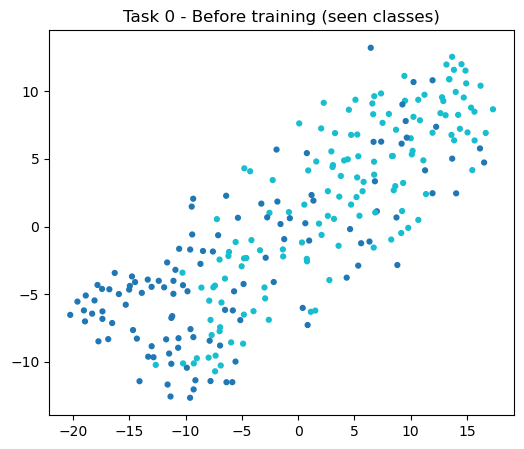

Task 0: 100%|██████████| 200/200 [31:33<00:00,  9.47s/epoch]


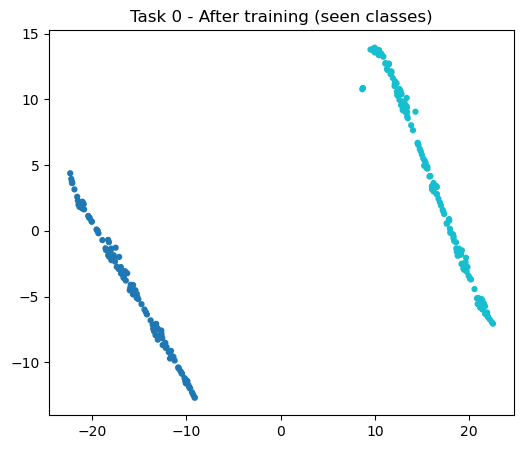

Training task 1


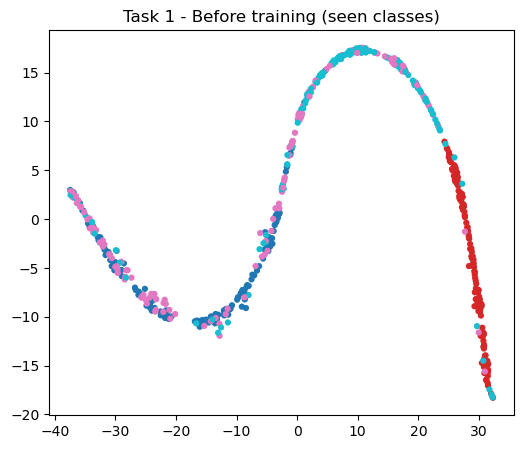

Task 1:   8%|▊         | 15/200 [36:39<7:32:03, 146.61s/epoch] 


KeyboardInterrupt: 

In [31]:
from utils import deterministic
from replay_buffer import ReplayBuffer
from backbone import BackBone
from losses.supcon import SupConLoss
from dataset import get_data_loaders
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import copy
import torchvision.transforms.v2 as v2
from tqdm import tqdm

def distill_criterion(s, t, tau_s=0.2, tau_t=0.01):
    sim_s = s @ s.T
    sim_t = t @ t.T

    eye = torch.eye(sim_s.size(0), device=sim_s.device, dtype=torch.bool)
    sim_s = sim_s.masked_fill(eye, -1e9)
    sim_t = sim_t.masked_fill(eye, -1e9)

    log_p_s = sim_s / tau_s - torch.logsumexp(sim_s / tau_s, dim=1, keepdim=True)
    log_p_t = sim_t / tau_t - torch.logsumexp(sim_t / tau_t, dim=1, keepdim=True)
    p_t = log_p_t.exp().detach()

    loss = -(p_t * log_p_s).sum(dim=1).mean()
    return loss * (tau_s ** 2)

def collect_seen_samples(dataloaders, max_task_idx, max_samples_per_task=256):
    x_chunks, y_chunks = [], []
    for task_idx in range(max_task_idx + 1):
        seen = 0
        train_loader = dataloaders[task_idx][0]
        for x_batch, y_batch in train_loader:
            take = min(x_batch.size(0), max_samples_per_task - seen)
            if take <= 0:
                break
            x_chunks.append(x_batch[:take])
            y_chunks.append(y_batch[:take])
            seen += take
    x_all = torch.cat(x_chunks, dim=0)
    y_all = torch.cat(y_chunks, dim=0)
    return x_all, y_all

def plot_task_tsne(backbone_model, x_ref, y_ref, plot_title):
    backbone_model.eval()
    with torch.no_grad():
        emb = backbone_model.get_projection(x_ref).detach().cpu().numpy()
    y_np = y_ref.detach().cpu().numpy()

    if emb.shape[0] < 2:
        return

    tsne = TSNE(n_components=2, random_state=42)
    emb_2d = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 5))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=y_np, cmap="tab10", s=12)
    plt.title(plot_title)
    plt.show()
    backbone_model.train()

deterministic(42)
title = "Co2L"
epochs = 200
batch_size = 512
buffer_size = 1000
buffer_batch_size = batch_size // 4
lambda_ = 1.0
distill_tau_s = 0.2
distill_tau_t = 0.01
tsne_samples_per_task = 256

backbone = torch.compile(BackBone().to(device), dynamic=True) # Supuestamente va mas rapido pero creo que no cambia nada

optimizer = torch.optim.SGD(backbone.parameters(), lr=0.5, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
supcon_criterion = SupConLoss(tau=0.07)

view_transform = v2.Compose([
    v2.RandomResizedCrop(size=(32, 32), scale=(0.6, 1.0)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandAugment(num_ops=2, magnitude=9),
]).to(device)

dataloaders = get_data_loaders(batch_size=batch_size, num_workers=0)
buffer = ReplayBuffer(buffer_size)
prev_backbone = None

for task in range(len(dataloaders)):
    print(f"Training task {task}")
    train_data = dataloaders[task][0]

    x_ref_cpu, y_ref_cpu = collect_seen_samples(
        dataloaders=dataloaders,
        max_task_idx=task,
        max_samples_per_task=tsne_samples_per_task,
    )
    x_ref = x_ref_cpu.to(device, non_blocking=True)
    y_ref = y_ref_cpu.to(device, non_blocking=True)

    plot_task_tsne(backbone, x_ref, y_ref, f"Task {task} - Before training (seen classes)")

    if prev_backbone is not None:
        buffer_loader = buffer.get_dataloader(buffer_batch_size)  # once per task

    epoch_bar = tqdm(range(epochs), desc=f"Task {task}", unit="epoch", miniters=50)
    for epoch in epoch_bar:
        if prev_backbone is not None:
            buffer_iter = iter(buffer_loader)  # just reset the iterator
        
        for x, y in train_data:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            N_cur = len(x) 

            if prev_backbone is not None:
                try:
                    x_buf, y_buf = next(buffer_iter)
                except StopIteration:
                    buffer_iter = iter(buffer_loader)
                    x_buf, y_buf = next(buffer_iter)

                x_buf = x_buf.to(device, non_blocking=True)
                y_buf = y_buf.to(device, non_blocking=True)
                x_all = torch.cat([x, x_buf], dim=0)
                y_all = torch.cat([y, y_buf], dim=0)
            else:
                x_all, y_all = x, y

            N_all = len(x_all)

            x_view1 = view_transform(x_all)
            x_view2 = view_transform(x_all)
            x_two_views = torch.cat([x_view1, x_view2], dim=0)
            class_labels = y_all.repeat(2)

            # x_two_views = [view1_current | view1_buffer | view2_current | view2_buffer]
            anchor_mask = torch.zeros(2 * N_all, dtype=torch.bool, device=device)
            anchor_mask[:N_cur] = True               # view1 of current task
            anchor_mask[N_all:N_all + N_cur] = True  # view2 of current task

            projections = backbone.get_projection(x_two_views)
            loss = supcon_criterion(projections, class_labels, anchor_mask=anchor_mask)

            if prev_backbone is not None:
                with torch.no_grad():
                    prev_projections = prev_backbone.get_projection(x_two_views)
                d_loss = distill_criterion(
                    projections,
                    prev_projections,
                    tau_s=distill_tau_s,
                    tau_t=distill_tau_t,
                )
                loss = loss + lambda_ * d_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()  

    plot_task_tsne(backbone, x_ref, y_ref, f"Task {task} - After training (seen classes)")

    prev_backbone = copy.deepcopy(backbone).eval()
    buffer.update(train_data)

backbone.save(f"../models/weights/{title}_Backbone.pth")

### Co2L utils

In [37]:
from utils import avg_accuracy_on_all_tasks, deterministic, extract_features_from_loader
from replay_buffer import ReplayBuffer
from dataset import get_data_loaders

from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

torch.set_float32_matmul_precision("high")

def extract_features_from_buffer(backbone, buffer_obj, device, chunk_size=512):
    if len(buffer_obj.buffer) == 0:
        empty_x = torch.empty((0, 3, 32, 32), device="cpu")
        empty_y = torch.empty((0,), dtype=torch.long, device="cpu")
        return empty_x, empty_y

    xs, ys = zip(*buffer_obj.buffer)
    x_all = torch.stack(xs, dim=0)
    y_all = torch.stack(ys, dim=0)

    feat_chunks = []
    backbone.eval()
    with torch.no_grad():
        for start in range(0, x_all.size(0), chunk_size):
            x_chunk = x_all[start:start + chunk_size].to(device, non_blocking=True)
            feat_chunks.append(backbone(x_chunk).cpu())
    return torch.cat(feat_chunks, dim=0), y_all

### Co2L TIL

In [38]:
def infer_task_and_local_labels(y_global, classes_per_task):
    task_ids = torch.div(y_global, classes_per_task, rounding_mode="floor").long()
    y_local = (y_global - task_ids * classes_per_task).long()
    return task_ids, y_local

def replay_loss_til_from_features(model, feat_buf, y_buf_global, criterion, classes_per_task):
    if feat_buf.numel() == 0 or y_buf_global.numel() == 0:
        return torch.tensor(0.0, device=feat_buf.device)

    task_ids, y_local = infer_task_and_local_labels(y_buf_global, classes_per_task)
    losses = []

    for replay_task in torch.unique(task_ids).tolist():
        mask = task_ids == replay_task
        pred_buf = model.heads[str(replay_task)](feat_buf[mask])
        losses.append(criterion(pred_buf, y_local[mask]))

    if len(losses) == 0:
        return torch.tensor(0.0, device=feat_buf.device)
    return torch.stack(losses).mean()

model = new_model_from_backbone(device, path="../models/weights/Co2L_Backbone.pth")
model.backbone.eval()
criterion = CrossEntropyLoss()
epochs = 50
title = "Co2L_TIL"
batch_size = 512
deterministic(42)
buffer_size = 1000
buffer = ReplayBuffer(buffer_size)
buffer_batch_size = batch_size // 4
classes_per_task = 2

dataloaders = get_data_loaders(batch_size=batch_size, num_workers=0)

all_accs_train = []
avg_val_acc = 0.0

for task in range(len(dataloaders)):
    model.add_head(task)
    model.to(device)
    model.train()
    model.backbone.eval()
    raw_train_loader = dataloaders[task][0]
    optimizer = torch.optim.Adam(model.heads.parameters(), lr=1e-2)

    feat_train_cpu, y_train_global_cpu = extract_features_from_loader(
        backbone=model.backbone,
        loader=raw_train_loader,
        device=device,
    )
    train_feat_loader = DataLoader(
        TensorDataset(feat_train_cpu, y_train_global_cpu),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )

    feat_replay_cpu, y_replay_global_cpu = extract_features_from_buffer(
        backbone=model.backbone,
        buffer_obj=buffer,
        device=device,
        chunk_size=batch_size,
    )

    epoch_bar = tqdm(range(epochs), desc=f"Task {task}", unit="epoch", miniters=20)
    for _ in epoch_bar:
        batch_bar = tqdm(train_feat_loader, leave=False, unit="batch", disable=True)

        for feat_cur_cpu, y_cur_global_cpu in batch_bar:
            feat_cur = feat_cur_cpu.to(device, non_blocking=True)
            y_cur_global = y_cur_global_cpu.to(device, non_blocking=True)
            y_cur_local = (y_cur_global - task * classes_per_task).long()

            optimizer.zero_grad(set_to_none=True)
            pred_cur = model.heads[str(task)](feat_cur)
            loss_cur = criterion(pred_cur, y_cur_local)
            loss = loss_cur

            if y_replay_global_cpu.numel() > 0:
                sample_size = min(buffer_batch_size, y_replay_global_cpu.size(0))
                idx = torch.randint(0, y_replay_global_cpu.size(0), (sample_size,))
                feat_buf = feat_replay_cpu[idx].to(device, non_blocking=True)
                y_buf_global = y_replay_global_cpu[idx].to(device, non_blocking=True)

                loss_buf = replay_loss_til_from_features(
                    model=model,
                    feat_buf=feat_buf,
                    y_buf_global=y_buf_global,
                    criterion=criterion,
                    classes_per_task=classes_per_task,
                )
                loss = loss_cur + loss_buf

            loss.backward()
            optimizer.step()

            batch_bar.set_postfix({"loss": float(loss.item()), "cur": float(loss_cur.item())})

        epoch_bar.set_postfix({"loss": float(loss.item())})

    buffer.update(raw_train_loader)

    accs = avg_accuracy_on_all_tasks(model, dataloaders, task)
    all_accs_train.append(accs)
avg_val_acc = sum(all_accs_train[-1]) / len(all_accs_train[-1])

accs = avg_accuracy_on_all_tasks(model, dataloaders, task, test=True)
avg_test_acc = sum(accs) / len(accs)

model.save(f"../models/weights/{title}.pth")

model_name = "Co2L"
mode_name = "til"
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_test_acc
all_val_accs_dic[model_name][mode_name] = all_accs_train

Files already downloaded and verified
Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000


Task 0: 100%|██████████| 50/50 [00:05<00:00,  9.54epoch/s, loss=0.058] 


|0: 0.9780|
Avg accuracy: 0.9780


Task 1: 100%|██████████| 50/50 [00:07<00:00,  7.04epoch/s, loss=0.363]


|0: 0.9720||1: 0.8670|
Avg accuracy: 0.9195


...

|0: 0.9670||1: 0.8450||2: 0.8990|
Avg accuracy: 0.9037


Task 3: 100%|██████████| 50/50 [00:08<00:00,  5.91epoch/s, loss=0.153]


|0: 0.9670||1: 0.8270||2: 0.8820||3: 0.9720|
Avg accuracy: 0.9120


Task 4: 100%|██████████| 50/50 [00:09<00:00,  5.33epoch/s, loss=0.0537]


|0: 0.9640||1: 0.8280||2: 0.8740||3: 0.9710||4: 0.9950|
Avg accuracy: 0.9264
|0: 0.9725||1: 0.8010||2: 0.8780||3: 0.9655||4: 0.9885|
Avg accuracy: 0.9211


### Co2L CIL

In [39]:
model = new_model_from_backbone(device, path="../models/weights/Co2L_Backbone.pth")
model.backbone.eval()
criterion = CrossEntropyLoss()
epochs = 50
title = "Co2L_CIL"
batch_size = 512
deterministic(42)
buffer_size = 1000
buffer = ReplayBuffer(buffer_size)
buffer_batch_size = batch_size // 4
classes_per_task = 2

dataloaders = get_data_loaders(batch_size=batch_size, num_workers=0)

all_val_accs = []
avg_val_acc = 0.0

for task in range(len(dataloaders)):
    print(f"Training task {task}")
    if task == 0:
        model.add_head(0, num_classes=classes_per_task)
    else:
        model.expand_head(number=0, num_class_increment=classes_per_task)

    model.to(device)
    model.train()
    model.backbone.eval()

    raw_train_loader = dataloaders[task][0]
    optimizer = torch.optim.Adam(model.heads.parameters(), lr=1e-2)

    feat_train_cpu, y_train_global_cpu = extract_features_from_loader(
        backbone=model.backbone,
        loader=raw_train_loader,
        device=device,
    )
    train_feat_loader = DataLoader(
        TensorDataset(feat_train_cpu, y_train_global_cpu),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )

    feat_replay_cpu, y_replay_global_cpu = extract_features_from_buffer(
        backbone=model.backbone,
        buffer_obj=buffer,
        device=device,
        chunk_size=batch_size,
    )

    epoch_bar = tqdm(range(epochs), desc=f"Task {task}", unit="epoch", miniters=20)
    for _ in epoch_bar:
        batch_bar = tqdm(train_feat_loader, leave=False, unit="batch", disable=True)

        for feat_cur_cpu, y_cur_global_cpu in batch_bar:
            feat_cur = feat_cur_cpu.to(device, non_blocking=True)
            y_cur_global = y_cur_global_cpu.to(device, non_blocking=True).long()

            optimizer.zero_grad(set_to_none=True)
            pred_cur = model.heads["0"](feat_cur)
            loss_cur = criterion(pred_cur, y_cur_global)
            loss = loss_cur

            if y_replay_global_cpu.numel() > 0:
                sample_size = min(buffer_batch_size, y_replay_global_cpu.size(0))
                idx = torch.randint(0, y_replay_global_cpu.size(0), (sample_size,))
                feat_buf = feat_replay_cpu[idx].to(device, non_blocking=True)
                y_buf_global = y_replay_global_cpu[idx].to(device, non_blocking=True).long()

                pred_buf = model.heads["0"](feat_buf)
                loss_buf = criterion(pred_buf, y_buf_global)
                loss = loss_cur + loss_buf

            loss.backward()
            optimizer.step()

            batch_bar.set_postfix({"loss": float(loss.item()), "cur": float(loss_cur.item())})

        epoch_bar.set_postfix({"loss": float(loss.item())})

    buffer.update(raw_train_loader)
    
    accs = avg_accuracy_on_all_tasks(model, dataloaders, task, cil=True)
    all_val_accs.append(accs)

avg_val_acc = sum(all_val_accs[-1]) / len(all_val_accs[-1])

accs = avg_accuracy_on_all_tasks(model, dataloaders, task, cil=True, test=True)
avg_accs_test = sum(accs) / len(accs)


model.save(f"../models/weights/{title}.pth")
model_name = "Co2L"
mode_name = "cil"
val_accs.loc[mode_name, model_name] = avg_val_acc
test_accs.loc[mode_name, model_name] = avg_accs_test
all_val_accs_dic[model_name][mode_name] = all_val_accs

Files already downloaded and verified
Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


Task 0: 100%|██████████| 50/50 [00:04<00:00, 10.04epoch/s, loss=0.058] 


|0: 0.9780|
Avg accuracy: 0.9780
Training task 1


Task 1: 100%|██████████| 50/50 [00:05<00:00,  8.61epoch/s, loss=0.605]


|0: 0.9090||1: 0.8120|
Avg accuracy: 0.8605
Training task 2


...

|0: 0.8960||1: 0.4360||2: 0.8260|
Avg accuracy: 0.7193
Training task 3


Task 3: 100%|██████████| 50/50 [00:05<00:00,  8.44epoch/s, loss=1.14] 


|0: 0.8700||1: 0.4390||2: 0.5470||3: 0.8980|
Avg accuracy: 0.6885
Training task 4


Task 4: 100%|██████████| 50/50 [00:06<00:00,  8.07epoch/s, loss=0.376]


|0: 0.8180||1: 0.5520||2: 0.6140||3: 0.7600||4: 0.9460|
Avg accuracy: 0.7380
|0: 0.8120||1: 0.5430||2: 0.5875||3: 0.7640||4: 0.9345|
Avg accuracy: 0.7282


### Results

In [40]:
print(val_accs)
print(test_accs)
print(all_val_accs_dic["Co2L"])

      Naive     EWC     LwF    Co2L
til  0.7964  0.7876  0.7952  0.9264
cil  0.1508  0.1498  0.1508   0.738
      Naive     EWC     LwF    Co2L
til  0.7893   0.786  0.7897  0.9211
cil  0.1517  0.1521  0.1517  0.7282
{'til': [[0.978], [0.972, 0.867], [0.967, 0.845, 0.899], [0.967, 0.827, 0.882, 0.972], [0.964, 0.828, 0.874, 0.971, 0.995]], 'cil': [[0.978], [0.909, 0.812], [0.896, 0.436, 0.826], [0.87, 0.439, 0.547, 0.898], [0.818, 0.552, 0.614, 0.76, 0.946]]}


## Save results

In [41]:
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
path = results_dir / "Co2L_results.pkl"

with path.open("wb") as file_handle:
    pickle.dump(
        {
            "val_accs": val_accs,
            "test_accs": test_accs,
            "all_val_accs_dic": all_val_accs_dic,
        },
        file_handle,
    )

## Show results

In [42]:
path = Path("../results/Co2L_results.pkl")
with path.open("rb") as file_handle:
    results = pickle.load(file_handle)

val_accs = results["val_accs"]
test_accs = results["test_accs"]
all_val_accs_dic = results["all_val_accs_dic"]

In [43]:
print("Validation avg accuracies:")
print(val_accs)
print("\nTest avg accuracies:")
print(test_accs)

Validation avg accuracies:
      Naive     EWC     LwF    Co2L
til  0.7964  0.7876  0.7952  0.9264
cil  0.1508  0.1498  0.1508   0.738

Test avg accuracies:
      Naive     EWC     LwF    Co2L
til  0.7893   0.786  0.7897  0.9211
cil  0.1517  0.1521  0.1517  0.7282



All average validation accuracies per task:
{'Naive': {'til': [0.976, 0.828, 0.792, 0.788, 0.7964], 'cil': [0.973, 0.2905, 0.201, 0.1557, 0.1508]}, 'EWC': {'til': [0.976, 0.827, 0.7917, 0.7795, 0.7876], 'cil': [0.973, 0.289, 0.1847, 0.1603, 0.1498]}, 'LwF': {'til': [0.976, 0.828, 0.7917, 0.7877, 0.7952], 'cil': [0.973, 0.291, 0.201, 0.1557, 0.1508]}, 'Co2L': {'til': [0.978, 0.9195, 0.9037, 0.912, 0.9264], 'cil': [0.978, 0.8605, 0.7193, 0.6885, 0.738]}}


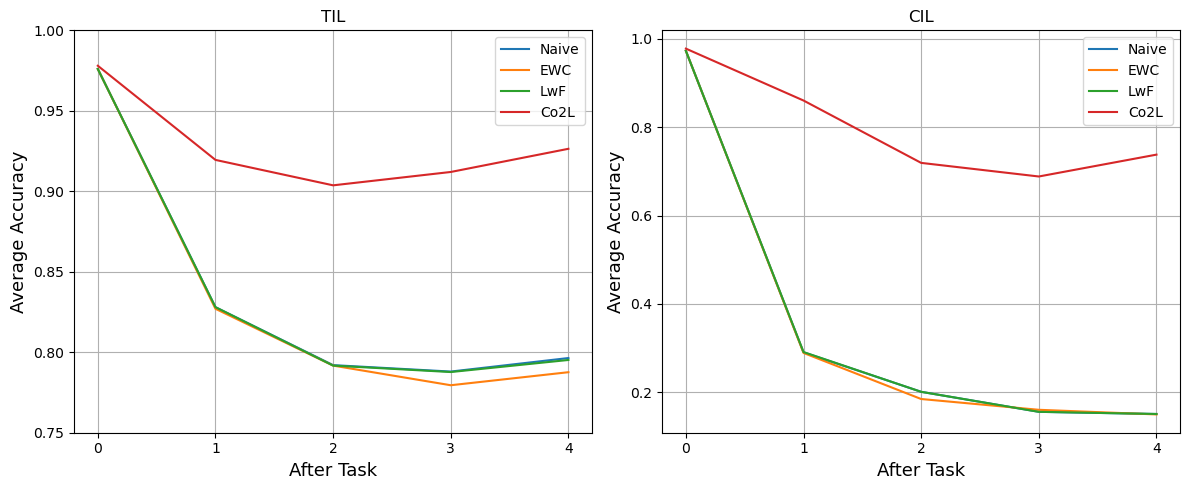

In [ ]:
all_val_avgs = {model: {mode: [] for mode in modes} for model in models}
for model in models:
    for mode in modes:
        accs = all_val_accs_dic[model][mode]
        avgs = [round(sum(acc_list) / len(acc_list), 4) for acc_list in accs]
        all_val_avgs[model][mode] = avgs

print("\nAll average validation accuracies per task:")
print(all_val_avgs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for model in models:
    axes[0].plot(all_val_avgs[model]["til"], label=model)
    axes[1].plot(all_val_avgs[model]["cil"], label=model)
axes[0].set_title("TIL")
axes[1].set_title("CIL")
axes[0].set_xlabel("After Task", fontsize=13)
axes[1].set_xlabel("After Task", fontsize=13)
axes[0].set_ylabel("Average Accuracy", fontsize=13)
axes[1].set_ylabel("Average Accuracy", fontsize=13)
axes[0].grid()
axes[1].grid()
axes[0].legend()
axes[1].legend()
axes[0].set_xticks(range(5))
axes[1].set_xticks(range(5))
axes[0].set_yticks([1, 0.75, 0.8, 0.85, 0.9, 0.95])
plt.tight_layout()
path = "../images/average_accuracies.png"
os.makedirs(os.path.dirname(path), exist_ok=True)
fig.savefig(path, dpi=300, bbox_inches="tight")

plt.show()

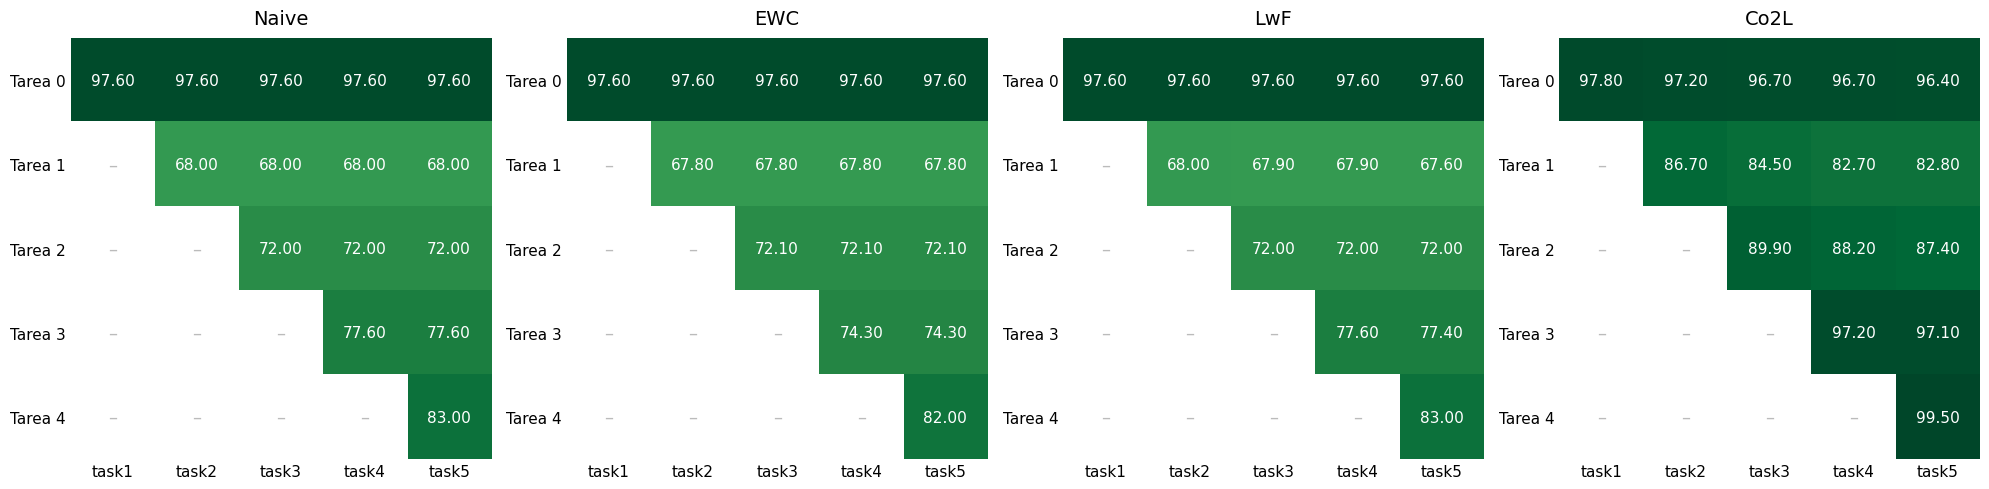

Guardado: ../images/til_heatmap.png


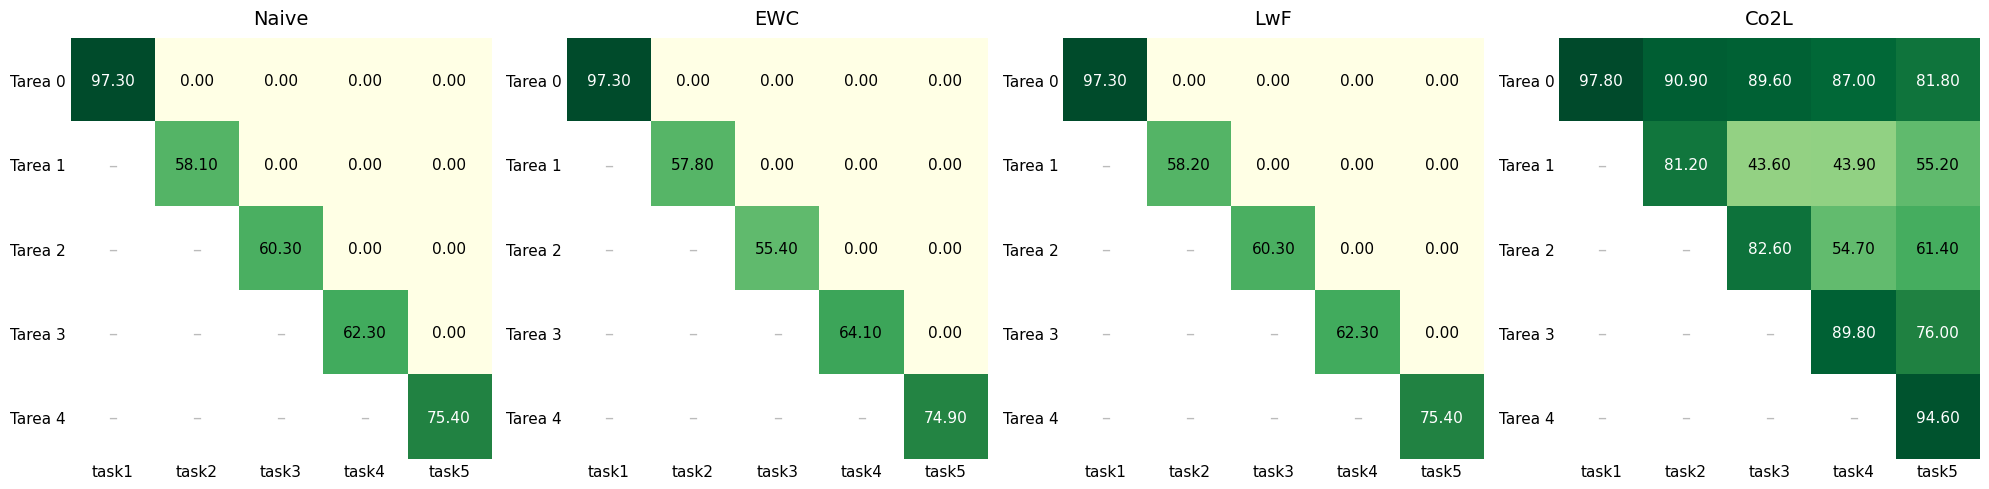

Guardado: ../images/cil_heatmap.png


In [58]:
import matplotlib.pyplot as plt
import numpy as np

def build_matrix(snapshots):
    n = len(snapshots[-1])  # número total de tareas
    matrix = np.full((n, n), np.nan)
    for step, row in enumerate(snapshots):
        for task_idx, val in enumerate(row):
            matrix[task_idx, step] = val
    return matrix

def plot_heatmaps(setting, filename):
    """
    setting: 'til' o 'cil'
    """
    models = list(all_val_accs_dic.keys())
    n_tasks = 5
    task_labels = [f'Tarea {i}' for i in range(n_tasks)]

    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))
    fig.patch.set_facecolor('white')

    for ax, model in zip(axes, models):
        snapshots = all_val_accs_dic[model][setting]
        matrix = build_matrix(snapshots)

        ax.imshow(np.zeros((n_tasks, n_tasks)), cmap='Greys',
                  vmin=0, vmax=1, alpha=0.08, aspect='auto')

        masked = np.ma.masked_invalid(matrix)
        ax.imshow(masked, cmap='YlGn', vmin=0, vmax=1, aspect='auto')

        for i in range(n_tasks):
            for j in range(n_tasks):
                val = matrix[i, j]
                if not np.isnan(val):
                    text_color = 'white' if val > 0.65 else 'black'
                    ax.text(j, i, f'{val*100:.2f}',
                            ha='center', va='center',
                            fontsize=11, color=text_color, fontweight='500')
                else:
                    ax.text(j, i, '–',
                            ha='center', va='center',
                            fontsize=13, color='#bbbbbb')

        ax.set_title(model, fontsize=14, fontweight='500', pad=10)
        ax.set_xticks(range(n_tasks))
        ax.set_xticklabels([f'task{i+1}' for i in range(n_tasks)], fontsize=11)
        ax.set_yticks(range(n_tasks))
        ax.set_yticklabels(task_labels, fontsize=11)
        ax.tick_params(length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {filename}')


plot_heatmaps('til', '../images/til_heatmap.png')
plot_heatmaps('cil', '../images/cil_heatmap.png')